In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [7]:
def get_theta(theta_min, theta_max, num_theta):
    ARCMIN_TO_RAD = 2.90888208665721580e-4
    RAD_TO_ARCMIN = 1/ARCMIN_TO_RAD

    THETA_MIN_RAD = theta_min * ARCMIN_TO_RAD
    THETA_MAX_RAD = theta_max * ARCMIN_TO_RAD
    DLOG_THETA = (np.log(THETA_MAX_RAD) - np.log(THETA_MIN_RAD))/num_theta
    theta = np.zeros(num_theta)
    for i in range(num_theta):
        THETA_MIN_BIN = np.exp(np.log(THETA_MIN_RAD) + i * DLOG_THETA)
        THETA_MAX_BIN = np.exp(np.log(THETA_MIN_RAD) + (i + 1) * DLOG_THETA)
        theta[i] = (2/3) * (THETA_MAX_BIN**3 - THETA_MIN_BIN**3) / (THETA_MAX_BIN**2 - THETA_MIN_BIN**2)

    theta *= RAD_TO_ARCMIN
    return theta


In [8]:
theta = get_theta(2.5, 900, 15) # from data/example1.dataset

In [9]:
_, dv_spk   = np.loadtxt("SPK.modelvector", unpack=True)
_, dv_bcemu = np.loadtxt("BCEMU.modelvector", unpack=True)
_, dv_fla   = np.loadtxt("FLAMINGO.modelvector", unpack=True)
_, dv_bacco   = np.loadtxt("BACCOEMU.modelvector", unpack=True)
_, dv_dmo   = np.loadtxt("DMO.modelvector", unpack=True)

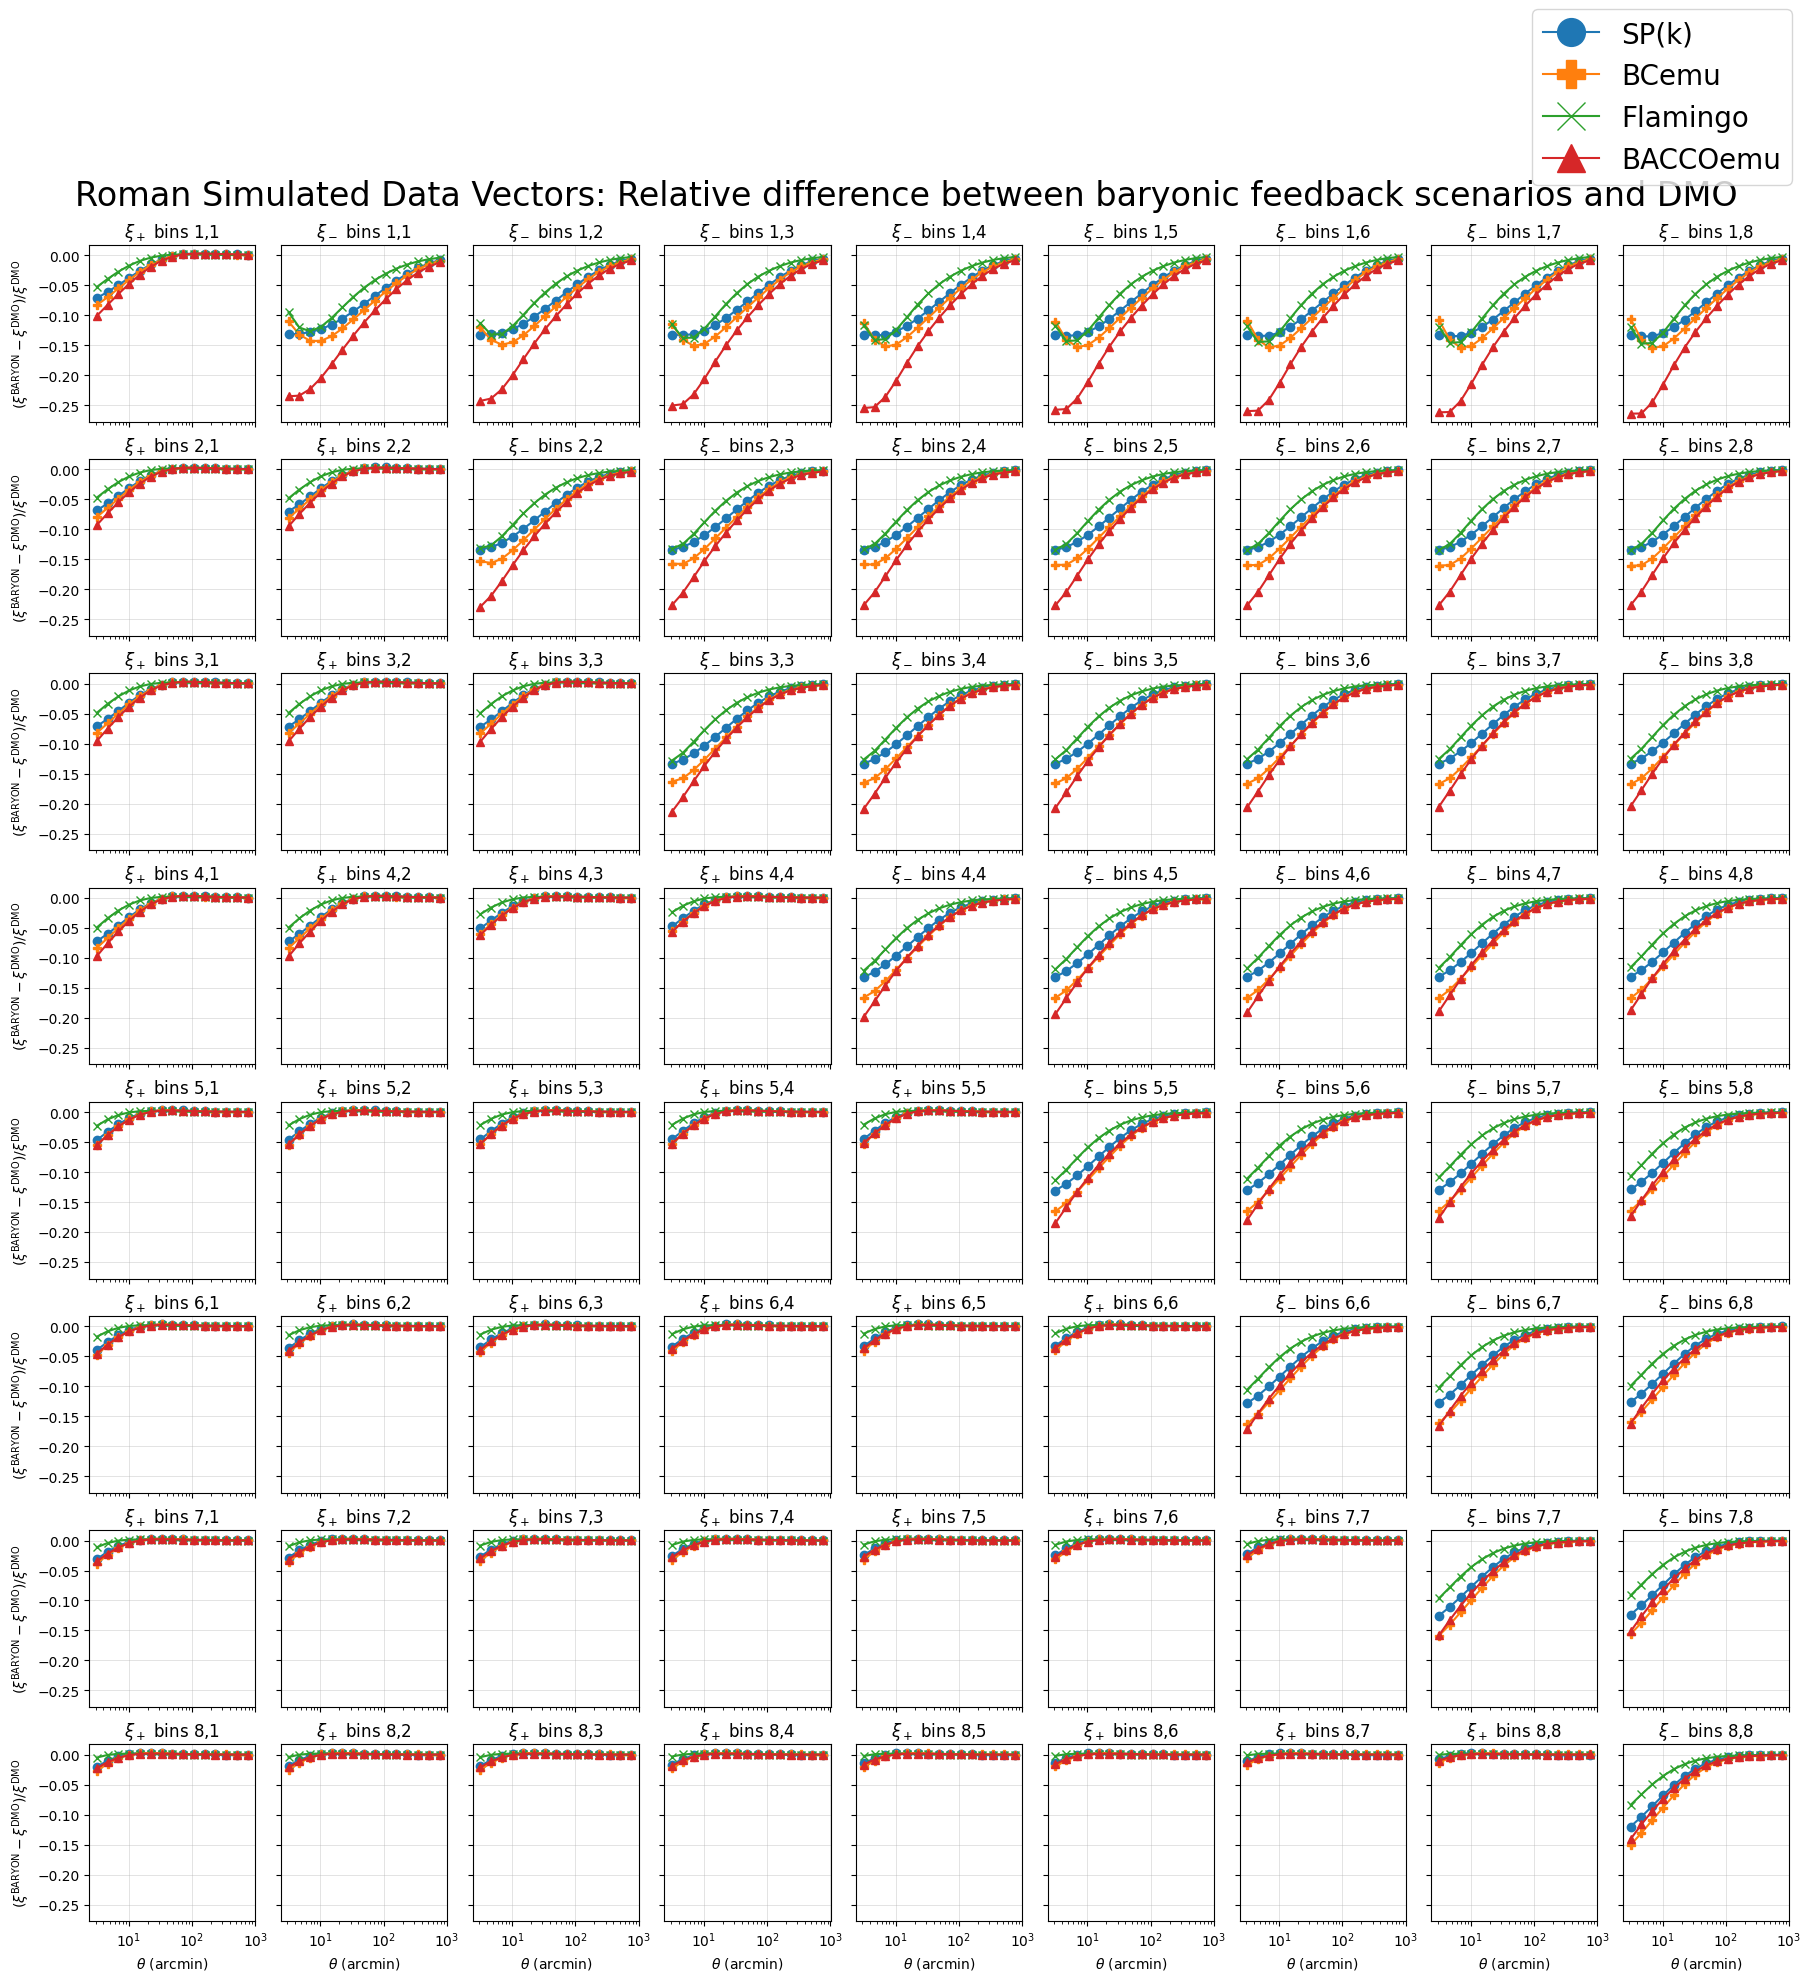

In [10]:
num_bins = 8
num_cols = num_bins+1
block_size = 15
tri_count = num_bins * (num_bins + 1) // 2

xi_plus_spk = dv_spk[:tri_count * block_size]
xi_minus_spk = dv_spk[tri_count * block_size:2 * tri_count * block_size]
xi_plus_bcemu = dv_bcemu[:tri_count * block_size]
xi_minus_bcemu = dv_bcemu[tri_count * block_size:2 * tri_count * block_size]
xi_plus_bacco = dv_bacco[:tri_count * block_size]
xi_minus_bacco = dv_bacco[tri_count * block_size:2 * tri_count * block_size]
xi_plus_fla = dv_fla[:tri_count * block_size]
xi_minus_fla = dv_fla[tri_count * block_size:2 * tri_count * block_size]
xi_plus_dmo = dv_dmo[:tri_count * block_size]
xi_minus_dmo = dv_dmo[tri_count * block_size:2 * tri_count * block_size]

fig, axes = plt.subplots(num_bins, num_cols, figsize=(18, 18), sharex=True, sharey=True, constrained_layout=True)
plus_idx = 0
minus_idx = 0

for i in range(num_bins):
    for col in range(num_cols):
        ax = axes[i, col]

        if col <= i:
            j = col
            start = plus_idx * block_size
            end = start + block_size
            rel_err_spk = (xi_plus_spk[start:end] - xi_plus_dmo[start:end])/xi_plus_dmo[start:end]
            rel_err_bcemu = (xi_plus_bcemu[start:end] - xi_plus_dmo[start:end])/xi_plus_dmo[start:end]
            rel_err_fla = (xi_plus_fla[start:end] - xi_plus_dmo[start:end])/xi_plus_dmo[start:end]
            rel_err_bacco = (xi_plus_bacco[start:end] - xi_plus_dmo[start:end])/xi_plus_dmo[start:end]
            ax.semilogx(theta, rel_err_spk, color='C0', marker='o', linestyle='-')
            ax.semilogx(theta, rel_err_bcemu, color='C1', marker='P', linestyle='-')
            ax.semilogx(theta, rel_err_fla, color='C2', marker='x', linestyle='-')
            ax.semilogx(theta, rel_err_bacco, color='C3', marker='^', linestyle='-')
            line_idx = plus_idx
            plus_idx += 1
            label = r'$\xi_+$'
        else:
            j = col - 1
            start = minus_idx * block_size
            end = start + block_size
            rel_err_spk = (xi_minus_spk[start:end] - xi_minus_dmo[start:end])/xi_minus_dmo[start:end]
            rel_err_bcemu = (xi_minus_bcemu[start:end] - xi_minus_dmo[start:end])/xi_minus_dmo[start:end]
            rel_err_fla = (xi_minus_fla[start:end] - xi_minus_dmo[start:end])/xi_minus_dmo[start:end]
            rel_err_bacco = (xi_minus_bacco[start:end] - xi_minus_dmo[start:end])/xi_minus_dmo[start:end]
            ax.semilogx(theta, rel_err_spk, color='C0', marker='o', linestyle='-')
            ax.semilogx(theta, rel_err_bcemu, color='C1', marker='P', linestyle='-')
            ax.semilogx(theta, rel_err_fla, color='C2', marker='x', linestyle='-')
            ax.semilogx(theta, rel_err_bacco, color='C3', marker='^', linestyle='-')
            line_idx = tri_count + minus_idx
            minus_idx += 1
            label = r'$\xi_-$'

        if i == num_bins - 1:
            ax.set_xlabel('$\\theta$ (arcmin)')
        if col == 0:
            ax.set_ylabel('$(\\xi^\\mathrm{BARYON} - \\xi^\\mathrm{DMO}) / \\xi^\\mathrm{DMO}$')

        ax.set_title(f'{label} bins {i+1},{j+1}', fontsize=12)
        ax.grid(True, linewidth=0.5, alpha=0.5)

handles = [
    Line2D([], [], marker="o", color="C0", markersize=20, label="SP(k)"),
    Line2D([], [], marker="P", color="C1", markersize=20, label="BCemu"),
    Line2D([], [], marker="x", color="C2", markersize=20, label="Flamingo"),
    Line2D([], [], marker="^", color="C3", markersize=20, label="BACCOemu"),
]
fig.legend(handles=handles, bbox_to_anchor=(1, 1.1), fontsize=20)

fig.suptitle('Roman Simulated Data Vectors: Relative difference between baryonic feedback scenarios and DMO', fontsize=24)
plt.show()